In [6]:
from pathlib import Path
import pandas as pd

candidates = [
    Path("eval/evaluation/outputs/eval/experiment_logs/phase1_retrieval_experiments.csv"),
    Path("../eval/evaluation/outputs/eval/experiment_logs/phase1_retrieval_experiments.csv"),
]

log_path = next(path for path in candidates if path.exists())

df = pd.read_csv(log_path)

cols = [
    "experiment_name",
    "retriever_type",
    "embedding_model",
    "reranker",
    "overall_hit_at_5",
    "overall_mrr_at_5",
    "overall_ndcg_at_5",
]

summary = df[cols].copy()
summary

,experiment_name,retriever_type,embedding_model,reranker,overall_hit_at_5,overall_mrr_at_5,overall_ndcg_at_5
0,01_bm25_canonical,bm25,text-embedding-3-small,False,0.576,0.565333,0.568095
1,02_dense_openai_small_canonical,dense,text-embedding-3-small,False,0.584,0.574667,0.577095
2,03_hybrid_openai_small_canonical,hybrid,text-embedding-3-small,False,0.578,0.565000,0.568357
3,04_hybrid_openai_small_rerank_canonical,hybrid,text-embedding-3-small,True,0.586,0.576333,0.578833
4,01_bm25_canonical_multi_filter_fix,bm25,text-embedding-3-small,False,0.976,0.949167,0.830159
5,02_dense_openai_small_canonical_multi_filter_fix,dense,text-embedding-3-small,False,0.976,0.950067,0.845504
6,03_hybrid_openai_small_canonical_multi_filter_fix,hybrid,text-embedding-3-small,False,0.978,0.948833,0.830016
7,04_hybrid_openai_small_rerank_canonical_multi_...,hybrid,text-embedding-3-small,True,0.986,0.964900,0.839861


In [7]:
summary.sort_values("overall_hit_at_5", ascending=False)

,experiment_name,retriever_type,embedding_model,reranker,overall_hit_at_5,overall_mrr_at_5,overall_ndcg_at_5
7,04_hybrid_openai_small_rerank_canonical_multi_...,hybrid,text-embedding-3-small,True,0.986,0.964900,0.839861
6,03_hybrid_openai_small_canonical_multi_filter_fix,hybrid,text-embedding-3-small,False,0.978,0.948833,0.830016
4,01_bm25_canonical_multi_filter_fix,bm25,text-embedding-3-small,False,0.976,0.949167,0.830159
5,02_dense_openai_small_canonical_multi_filter_fix,dense,text-embedding-3-small,False,0.976,0.950067,0.845504
3,04_hybrid_openai_small_rerank_canonical,hybrid,text-embedding-3-small,True,0.586,0.576333,0.578833
1,02_dense_openai_small_canonical,dense,text-embedding-3-small,False,0.584,0.574667,0.577095
2,03_hybrid_openai_small_canonical,hybrid,text-embedding-3-small,False,0.578,0.565000,0.568357
0,01_bm25_canonical,bm25,text-embedding-3-small,False,0.576,0.565333,0.568095


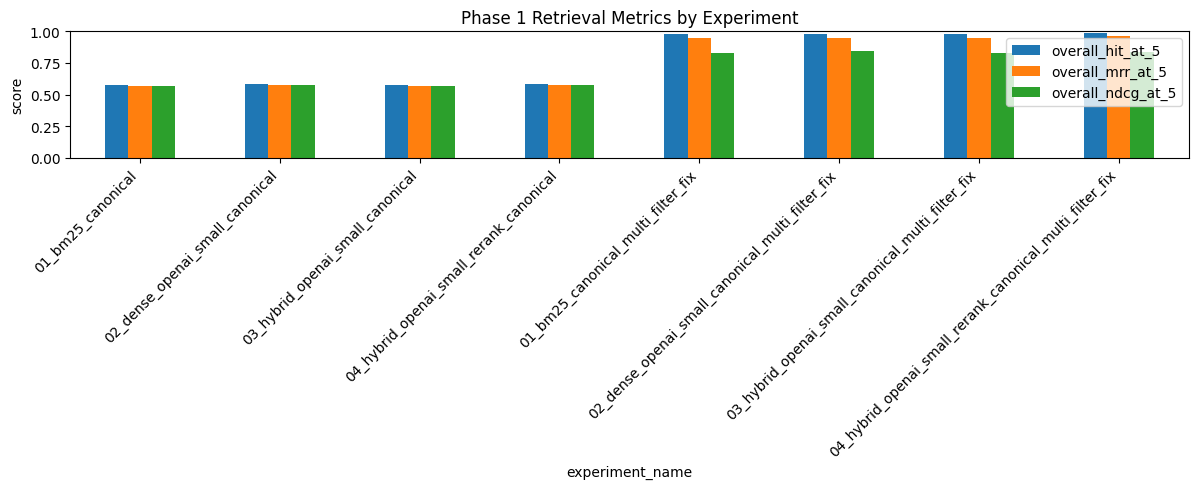

In [8]:
import matplotlib.pyplot as plt

plot_df = summary.set_index("experiment_name")[
    ["overall_hit_at_5", "overall_mrr_at_5", "overall_ndcg_at_5"]
]

ax = plot_df.plot(kind="bar", figsize=(12, 5))
ax.set_ylim(0, 1)
ax.set_ylabel("score")
ax.set_title("Phase 1 Retrieval Metrics by Experiment")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()